# Try It Yourself: Add a Multi-CSV Dataset with the Agent

Notebook 3 ran the agentic workflow on an easy dataset: Montgomery is one CSV,
one image per study, a single binary label. Now it is your turn on a harder one,
using the same skill and the same three steps (describe, scaffold, verify).

The data is a 200-study subsample of MIMIC-CXR, harder in four ways, each
something you must describe to the agent:

- **Three CSVs, not one.** Metadata, labels, and reports in separate files that
  join on `subject_id` and `study_id`.
- **DICOM images**, not PNG.
- **One study, many images.** A study can carry several views, so `study_id`
  and `patient_id` are distinct.
- **Two outputs.** Both the 14 CheXpert labels and the free-text report.

Same skill ([docs/add_dataset_skill.md](../docs/add_dataset_skill.md)), same
loop: inspect, prompt, verify. Try writing the prompt yourself before peeking at
the reference spec.

## How it works

The loop is identical to notebook 3:

1. **You describe the data** (below): the three CSVs, their join keys, the
   column mapping, and the two outputs.
2. **The agent scaffolds it**, guided by the skill: config, harmonizer,
   dataset, exports, integrity check, pausing for you to review each edit.
3. **You verify**: load the dataset by name and run the same check CI uses.

Open Claude Code in the repo root. This notebook holds the data inspection you
feed the agent and the verification you run afterward.

## Step 1: inspect the data

Read all three CSVs and work out the mapping before you prompt anything. Note:

- which columns are the join keys,
- the `files/` prefix on the image path,
- how many images each study has,
- that the report text is stored inline (not as a file path).

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))
from basepaths import *

In [2]:
import pandas as pd

DATA = f"{SESSION_DATA}/mimic_cxr_toy"  # the three toy CSVs
# MIMIC_DIR = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/files/"  # DICOM root

metadata = pd.read_csv(f"{DATA}/metadata.csv")  # one row per image
labels = pd.read_csv(f"{DATA}/labels.csv")  # one row per study
reports = pd.read_csv(f"{DATA}/reports.csv")  # one row per study

print("metadata:", metadata.shape, "->", list(metadata.columns))
print("labels:  ", labels.shape, "->", list(labels.columns))
print("reports: ", reports.shape, "->", list(reports.columns))
print()
print(
    "studies:",
    metadata["study_id"].nunique(),
    "| images:",
    len(metadata),
    "| max images per study:",
    metadata.groupby("study_id").size().max(),
)
print("image path example:", metadata["path"].iloc[0])
print()
print("one report (first 280 chars):")
print(reports["report"].iloc[0][:280])
metadata.head()

metadata: (331, 4) -> ['subject_id', 'study_id', 'dicom_id', 'path']
labels:   (200, 16) -> ['subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']
reports:  (200, 3) -> ['subject_id', 'study_id', 'report']

studies: 200 | images: 331 | max images per study: 4
image path example: files/p10/p10027957/s50867638/3b4a49ca-8676e2ac-f556fe29-09fa3269-4d98a4d2.dcm

one report (first 280 chars):
FINAL REPORT
 EXAMINATION:
 Chest:  Frontal and lateral views
 
 INDICATION:  History: ___F with CP, SOB  // eval for PNA
 
 TECHNIQUE:  Chest:  Frontal and Lateral
 
 COMPARISON:  ___
 
 FINDINGS: 
 
 The lungs are clear without focal consolidation.  No pleural effusion or
 pneu


,subject_id,study_id,dicom_id,path
0,10027957,50867638,3b4a49ca-8676e2ac-f556fe29-09fa3269-4d98a4d2,files/p10/p10027957/s50867638/3b4a49ca-8676e2a...
1,10027957,50867638,ee911ba8-42c7ff10-899825dd-92c604f5-9b0cb32a,files/p10/p10027957/s50867638/ee911ba8-42c7ff1...
2,10126467,59023761,c6a89c4b-7c96f712-43b57843-0f0e013d-26dfdc8d,files/p10/p10126467/s59023761/c6a89c4b-7c96f71...
3,10126467,59023761,e4615c42-06304239-bb7eae3e-2f980aaa-9b7d583c,files/p10/p10126467/s59023761/e4615c42-0630423...
4,10165672,52806049,15da8280-c72c297a-ab9416be-6eb22eb4-4873026a,files/p10/p10165672/s52806049/15da8280-c72c297...


## Step 2: write the prompt

Your turn. Describe the dataset to the agent and let it follow the skill. Work
out these decisions from what you just inspected:

- **Join keys** shared by all three CSVs (which two columns?).
- **`patient_id` and `study_id`**: which raw columns? (They are not the same
  here.)
- **`image_path`**: the `path` column carries a leading `files/` that is already
  part of `base_image_dir`. That is a `derivation`: describe it in words (see
  notebook 3), for example `"strip the leading files/ prefix"`.
- **Labels**: 14 CheXpert columns in a separate CSV, joined on the keys.
- **Reports**: the text is inline in the `report` column of a separate CSV
  (not a path to a `.txt` file), so the harmonizer merges that column directly
  rather than reading files from disk. Tell the agent this explicitly.
- **Outputs**: classification and report; no masks or bounding boxes.


Try writing it yourself first. When you want to check your work, here is a
reference structured spec you can hand the agent:

> Use the add-dataset skill in `docs/add_dataset_skill.md` to add a dataset from
> this spec.
>
> ```json
> {
>   "dataset_name": "My MIMIC-CXR (toy)",
>   "registry_key": "my_mimic",
>   "modality": "2D",
>   "image_format": "DICOM",
>   "base_image_dir": "/mnt/efs/cxr/MIMIC-CXR-V2-AWS/files/",
>   "primary_csv": {"path": "/mnt/efs/cxr/session_data/mimic_cxr_toy/metadata.csv"},
>   "patient_id": {"column": "subject_id", "derivation": null},
>   "study_id": {"column": "study_id", "derivation": null},
>   "image_path": {"column": "path", "derivation": "strip the leading files/ prefix"},
>   "labels": {
>     "columns": ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
>                 "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion",
>                 "Lung Opacity", "No Finding", "Pleural Effusion",
>                 "Pleural Other", "Pneumonia", "Pneumothorax",
>                 "Support Devices"],
>     "separate_csv": {"path": "/mnt/efs/cxr/session_data/mimic_cxr_toy/labels.csv",
>                      "join_columns": ["subject_id", "study_id"]}
>   },
>   "reports": {
>     "supported": true,
>     "separate_csv": {"path": "/mnt/efs/cxr/session_data/mimic_cxr_toy/reports.csv",
>                      "join_columns": ["subject_id", "study_id"]},
>     "note": "report text is inline in the 'report' column; merge it directly, do not read files"
>   },
>   "masks": {"supported": false},
>   "bboxes": {"supported": false}
> }
> ```

## Step 3: verify the result

Once the agent has written the files, run the cells below. The first imports the
new dataset submodule directly, registering it in this session. If you ran these
cells before the files existed, restart the kernel (Kernel > Restart) so the
import is fresh. Adjust the constructor kwargs if you named them differently from
the reference spec.

registered: True
harmonized rows: 331 | columns: ['patient_id', 'study_id', 'image_path', 'atelectasis', 'cardiomegaly', 'consolidation', 'edema', 'enlarged_cardiomediastinum', 'fracture', 'lung_lesion', 'lung_opacity', 'no_finding', 'pleural_effusion', 'pleural_other', 'pneumonia', 'pneumothorax', 'support_devices', 'report']


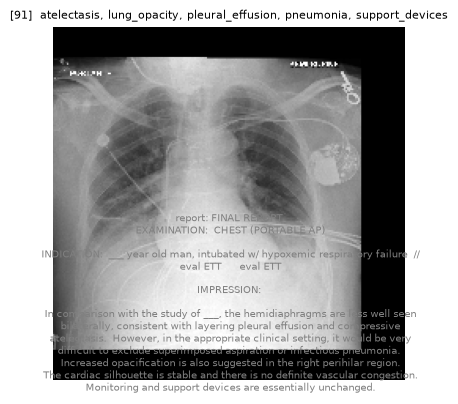

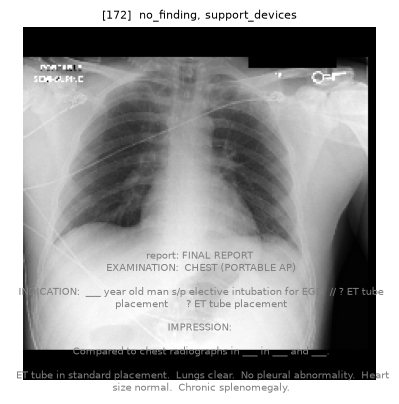

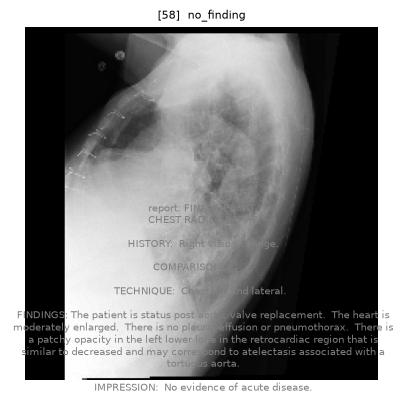

In [3]:
import matplotlib.pyplot as plt

# Import the new dataset submodule directly. This runs its @register_dataset
# decorator right away, so the dataset is live in this session without waiting
# on the top-level package exports (those load on the next kernel start).
import radharmony.dataset.my_mimic.my_mimic  # noqa: F401
from radharmony.registry import resolve_dataset, list_datasets

# Paths again, so this cell stands alone after a kernel restart.
DATA = f"{SESSION_DATA}/mimic_cxr_toy"
# MIMIC_DIR = "/mnt/NAS4/datasets/external/MIMIC-CXR-V2-AWS/files/"

print("registered:", "my_mimic" in list_datasets())

MyMIMICDataset = resolve_dataset("my_mimic")
ds = MyMIMICDataset(
    base_image_dir=MIMIC_DIR,
    csv_path=f"{DATA}/metadata.csv",
    label_csv_path=f"{DATA}/labels.csv",
    report_csv_path=f"{DATA}/reports.csv",
    output_cls=True,
    output_report=True,
    cache_dir=None,
)
df = ds.get_harmonized_df()
print("harmonized rows:", len(df), "| columns:", list(df.columns))
# print("\nsample report (first 280 chars):")
# print(str(df["report"].dropna().iloc[0])[:280])

# One figure per sample; build, then display each.
built = ds.get_datasets()
for fig in ds.visualize_samples(built, n=3):
    display(fig)
    plt.close(fig)

In [5]:
from radharmony.integrity import check_dataset, print_report, subsample_dataset

# The same check CI runs: harmonize, load a subsample, validate the image
# tensor plus the label vector (and that report text comes through).
check_ds = MyMIMICDataset(
    base_image_dir=MIMIC_DIR,
    csv_path=f"{DATA}/metadata.csv",
    label_csv_path=f"{DATA}/labels.csv",
    report_csv_path=f"{DATA}/reports.csv",
    output_cls=True,
    output_report=True,
    cache_dir=None,
)
subsample_dataset(check_ds, max_samples=30)  # fast pass over a subset
report = check_dataset(check_ds, num_workers=0)  # 0 workers is notebook-safe
print_report(report)

MyMIMICCXRDataset:   0%|          | 0/4 [00:00<?, ?it/s]

Applying a VOI LUT on a float input array may give incorrect results



✅  MyMIMICCXRDataset  [OK]
  Total time     : 9.5s
  Samples        : 30
  Success        : 30
  Failed         : 0
  Sample keys    : ['cls', 'img', 'report']

  img dtype      : torch.bfloat16
  img range      : [-1.0000, 1.0000]
  img NaN        : 0 samples
  img Inf        : 0 samples
  img shapes     :
    (1, 224, 224)                  x 30

  cls vector len : 14
  cls all-NaN    : 0 samples
  cls positive counts:
    [0]                                            4 / 30 ( 13.3%)
    [1]                                            5 / 30 ( 16.7%)
    [2]                                            2 / 30 (  6.7%)
    [3]                                            4 / 30 ( 13.3%)
    [4]                                            1 / 30 (  3.3%)
    [5]                                            0 / 30 (  0.0%)
    [6]                                            2 / 30 (  6.7%)
    [7]                                            8 / 30 ( 26.7%)
    [8]                                

## Recap

You added a multi-CSV dataset the same way notebook 3 added a single-CSV one (describe, scaffold, verify), this time handling three joined CSVs, a stripped `files/` prefix, multi-image studies, a merged report step, and two outputs. Compare your harmonizer against the production `mimic_cxr` one in `radharmony/harmonizer/` to see how close the agent got.